# Classification Models: From Binary Diagnosis to Multiclass Prediction

---

> ### 📋 Practice Exercise. Not Graded.
> This is a **practice assignment** for self-assessment. The marks shown throughout are **indicative only**. They tell you where to spend your effort and where you might need more practice. **None of these marks count towards your final grade.**
>
> Attempt every section. Compare your results. Revisit what trips you up.

---

## What You Will Build

Two classifiers, two datasets, one progression from simple to complex.

| Part | Dataset | Task | Primary Metric |
|------|---------|------|----------------|
| **Part 1** | Breast Cancer (sklearn) | Binary: Malignant vs Benign | Recall (Sensitivity) |
| **Part 2** | Wine (sklearn) | Multiclass: 3 wine cultivars | Macro-averaged F1-Score |

**Indicative Marks: 100** (Part 1: 55 | Part 2: 45)

### Before You Start
- Complete all cells marked with `# TODO`.
- Markdown cells marked **[Your Answer]** need written responses. Don't skip them.
- Run `Runtime > Restart and run all` before reviewing. The notebook should execute top to bottom without errors.
- Use `random_state=42` wherever a function accepts it. This keeps your results reproducible.


---
# PART 1: Binary Classification, Breast Cancer Prediction

## Context

Early detection of malignant tumours saves lives. In this part, you will build classifiers that predict whether a breast tumour is **malignant** or **benign** based on features computed from cell nuclei images.

**Why Recall matters here:** A false negative means telling a patient their tumour is benign when it is actually malignant. That is a missed cancer diagnosis. A false positive means an unnecessary follow-up test. Annoying, but survivable. The asymmetry is stark: we prioritise **recall for the malignant class** above everything else.

> **Clinical Constraint:** We want recall ≥ 0.95 for malignant cases, while keeping precision ≥ 0.60 (i.e., not flooding clinics with false alarms).


## Stage 1: Data and Package Loading

<font color="red">**[3 marks]**</font>

Load the Breast Cancer Wisconsin dataset from `sklearn.datasets`.

**What to do:**
- The libraries below are pre-imported. Review them, add anything else you need.
- Load the dataset using `load_breast_cancer()`
- Convert it to a DataFrame with proper column names
- Separate features (`X`) and target (`y`)

> **Watch out:** In the raw dataset, `0 = malignant` and `1 = benign`. Since `recall_score` defaults to `pos_label=1`, we need malignant to be 1. **Remap the target** with `y = 1 - data.target`.


In [1]:
# Pre-imported libraries. Review these, add what you need below.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, roc_auc_score,
                             precision_recall_curve)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')


In [2]:
# Load the breast cancer dataset and convert to DataFrame
data = load_breast_cancer()
### CODE HERE ###
X= data.data
y= data.target
df = pd.DataFrame(X, columns=data.feature_names)


In [3]:
# Separate features and target, remap so malignant = 1
### CODE HERE ###
df['target'] = y
# Remap target: y = 1 - target
df['target'] = 1 - df['target']
#df['target'] = df['target'].map({0:1, 1:0})
print(df['target'])


0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: target, Length: 569, dtype: int64


## Stage 2: Data Understanding

<font color="red">**[8 marks]**</font>

Before building any model, understand the data.


### 2.1 Basic Inspection <font color="red">[2 marks]</font>

Display the first few rows, check the shape, data types, and confirm there are no missing values.


In [4]:
# Display first 5 rows
### CODE HERE ###
print("\n1. Head (first 5 rows):")
df.head()


1. Head (first 5 rows):


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [5]:
# Check shape, data types, and missing values
### CODE HERE ###

print(f"\nShape: {df.shape}")
print("=" * 50)
print("\nData Types (dtypes):")
print(df.dtypes)
print("=" * 50)
print("\nNull Values (isnull().sum()):")
print(df.isnull().sum())



Shape: (569, 31)

Data Types (dtypes):
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave p

### 2.2 Summary Statistics <font color="red">[2 marks]</font>

Generate descriptive statistics. Pay attention to the **scale differences** across features. Some features range in the hundreds, others below 1. This matters for your preprocessing choices.


In [6]:
# Summary statistics
# Note the scale differences: mean radius is ~14, mean area is ~654, mean fractal dimension is ~0.06
### CODE HERE ###
print("\nSummary Statistics (describe):")
print("=" * 50)
print(df.describe())


Summary Statistics (describe):
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000  

### 2.3 Class Distribution <font color="red">[2 marks]</font>

How many malignant vs benign cases are there? Visualise this with a bar plot.


Class Distribution (value_counts):
target
0    357
1    212
Name: count, dtype: int64

Malignant cases: 212
Benign cases: 357


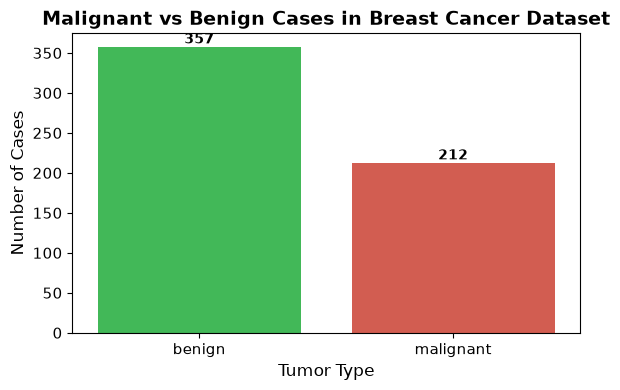

In [7]:
# Class distribution after remapping
### CODE HERE ###
from sklearn.datasets import load_breast_cancer #Imports the function to load the breast cancer dataset from scikit-learn
import pandas as pd # Imports pandas library for data manipulation
import matplotlib.pyplot as plt # Imports matplotlib for plotting
import seaborn as sns # Imports seaborn for statistical visualization

# Load the breast cancer dataset and convert to DataFrame
data = load_breast_cancer() #Loads the breast cancer dataset and stores it in  data  variable
X = data.data #Extracts the feature data (30 measurements per sample) from  data  and stores in  X
y = data.target #Extracts the target labels (0 or 1) from  data  and stores in  y
df = pd.DataFrame(X, columns=data.feature_names) #Creates a pandas DataFrame from  X , using the feature names as column headers
df['target'] = y #Adds a new column called ‘target’ to the DataFrame, containing the target labels

# Remap target: y = 1 - target
df['target'] = 1 - df['target'] #Remaps the target: flips 0→1 and 1→0 (so malignant becomes 1, benign becomes 0)

# Count malignant vs benign
print("Class Distribution (value_counts):")
print(df['target'].value_counts())

# Map numeric target to labels
target_labels = df['target'].map({0: 'benign', 1: 'malignant'}) #Converts numeric targets (0,1) to text labels (‘benign’, ‘malignant’)
counts = target_labels.value_counts() #Counts how many times each label appears (malignant vs benign cases)

print(f"\nMalignant cases: {counts.get('malignant', 0)}")
print(f"Benign cases: {counts.get('benign', 0)}")

# Create bar plot
plt.figure(figsize=(6, 4)) #Creates a new figure with width=6 inches, height=4 inches
sns.barplot(x=counts.index, y=counts.values, palette=['#2ecc4b', '#e74c3c']) #Creates a bar plot with labels on x-axis, counts on y-axis, green for benign, red for malignant
plt.title('Malignant vs Benign Cases in Breast Cancer Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Tumor Type', fontsize=12)
plt.ylabel('Number of Cases', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Add count numbers on top of each bar (enumerates gives index  i  and value  v )
for i, v in enumerate(counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


### 2.4 Feature Distributions <font color="red">[2 marks]</font>

Pick 4-6 features and plot their distributions using histograms or boxplots. Look for skewness, outliers, and whether the two classes separate visually on any feature.


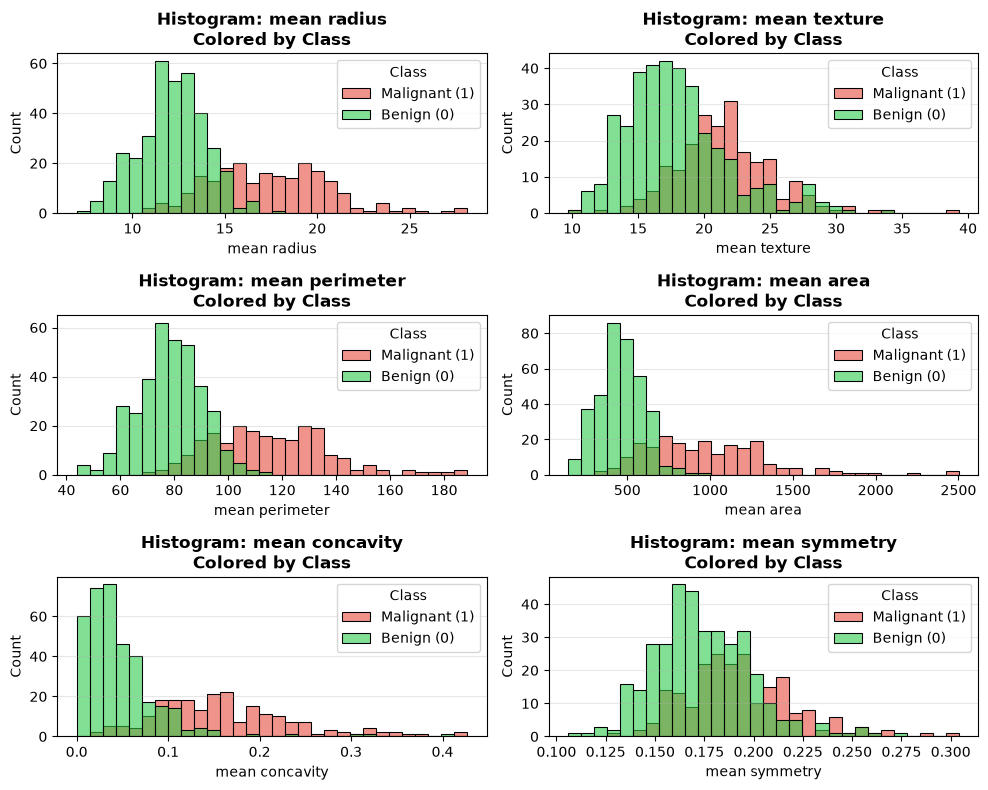

In [8]:
# Feature distributions for 6 selected features, coloured by class
### CODE HERE ###

features_to_plot = [
    'mean radius',
    'mean texture',
    'mean perimeter',
    'mean area',
    'mean concavity',
    'mean symmetry'
]

# Create histograms for each feature, colored by class
plt.figure(figsize=(10, 8))

for i, feature in enumerate(features_to_plot, 1): #Returns  (index, feature)  starting at 1 (not 0)
    plt.subplot(3, 2, i) #Creates a grid of subplots with 3 rows × 2 columns = 6 total positions

    # Create histograms for each class
    sns.histplot(
        data=df,
        x=feature,
        hue='target',
        palette=['#2ecc4b', '#e74c3c'],  # Malignant=red, Benign=green
        alpha=0.6, #Sets transparency to 60% (allows overlapping bars to be visible)
        bins=30, #Divides data into 30 intervals for the histogram
        edgecolor='black'
    )

    # Add title and labels
    plt.title(f'Histogram: {feature}\nColored by Class', fontsize=12, fontweight='bold')
    plt.xlabel(feature, fontsize=10)
    plt.ylabel('Count', fontsize=10)
    # Add grid
    plt.grid(axis='y', alpha=0.3) #Makes grid lines faint (30% opacity)

    plt.legend(['Malignant (1)', 'Benign (0)'], title='Class', fontsize=10)

plt.tight_layout()
plt.show()



### ✍️ Interpretation Checkpoint

**[Your Answer]:** Answer these questions in 2-3 sentences each:
1. Is the dataset balanced? How might imbalance affect model training?
2. Do the features have similar scales? What does this mean for models like KNN and SVM?
3. Why is recall a better primary metric than accuracy for this problem?
4. Why must we fit the scaler on training data only and not on the full dataset? What information from the test set would leak into training if we did?


*Write your answers here:*

1. ***your answer here*** Dataset is not balanced with 357 benign samples and 212 malignant samples.This imbalance can cause the model to become biased toward predicting the benign class, potentially achieving high accuracy while failing to detect malignant cases.

2. ***your answer here*** No.The features do not have similar scales—mean radius ranges around 6-28, mean texture around 9-40, mean perimeter around 43-188, and mean area can reach 2500+. This means KNN needs to be normalize and SVM needs to be scaled features equaly as they are sensitive to feature scaling because they use distance-based calculations; unscaled features with larger ranges (like area) will dominate the distance metric and distort predictions.We need to standardize/normalize features (e.g., using StandardScaler) so all features contribute equally to distance calculations.

3. ***your answer here*** Recall is better than accuracy for cancer diagnosis because we need to minimize false negatives (missing malignant cases), and recall measures how many actual malignant cases the model correctly identifies. Accuracy can be misleading—if a model predicts only benign cases, it achieves 62.7% accuracy (the majority class proportion) but has 0% recall for malignant, which is catastrophic in medical diagnosis where missing cancer is more dangerous than false alarms

4. ***your answer here***. We must fit the scaler on training data only to prevent data leakage—if we fit on the full dataset, the test set’s statistics (mean, variance, range) leak into the training process, artificially inflating performance metrics because the model indirectly “knows” about test data distribution. Specifically, the scaler’s learned parameters (mean and standard deviation from StandardScaler) would incorporate information from the test set, violating the principle that test data should be completely unseen during training, making evaluation biased and unreliable.


## Stage 3: Data Preprocessing and Preparation

<font color="red">**[7 marks]**</font>


### 3.1 Missing Value Audit <font color="red">[1 mark]</font>

Confirm no missing values exist. If any do, handle them with median imputation.


In [9]:
# Missing value audit
### CODE HERE ###
# Check if any missing values exist in feature columns (excluding target)
missing_before = df.iloc[:, :-1].isnull().sum()  # Exclude target column
total_missing = missing_before.sum()
print(total_missing)
if total_missing == 0:
    print("\n No missing values found in the dataset!")
else:
    print(f"\n Found {total_missing} missing values. Applying median imputation...")


0

 No missing values found in the dataset!


### 3.2 Train-Test Split <font color="red">[2 marks]</font>

Split into 70% training and 30% test using **stratified sampling** to preserve the class ratio to mitigate any slight class imbalance. Use `random_state=42`.


In [10]:
# Stratified train-test split
### CODE HERE ###
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,      # 30% test, 70% train
    stratify=y,         # Preserve class proportions
    random_state=42     # Reproducible results
)


### 3.3 Feature Scaling <font color="red">[2 marks]</font>

Apply `StandardScaler`. **Fit the scaler on training data only**, then transform both train and test sets. If you fit on the full dataset, the scaler learns the mean and standard deviation of the test data, which inflates your results. That is data leakage.

> **Note:** Decision Trees split on thresholds and don't need scaling. But for consistency here, we scale for all models.


In [11]:
# Feature scaling: fit on train only, transform both
### CODE HERE ###
# Create scaler
scaler = StandardScaler() #Creates a  StandardScaler  instance from scikit-learn’s preprocessing module

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



### 3.4 Confirm Prepared Data <font color="red">[2 marks]</font>

Print shapes of your final training and test sets. Verify the class distribution is preserved in both.


In [12]:
# Confirm prepared data
### CODE HERE ###
# Print shapes
print("\n1. Data Shapes:")
print(f"   X_train (unscaled): {X_train.shape}")
print(f"   X_train (scaled):   {X_train_scaled.shape}")
print(f"   X_test (unscaled):  {X_test.shape}")
print(f"   X_test (scaled):    {X_test_scaled.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   y_test:  {y_test.shape}")

y_train_series = pd.Series(y_train)  # Convert numpy array to Series
y_test_series = pd.Series(y_test)    # Convert numpy array to Series
print("\n Class Distribution in Training Set (y_train):")
print(y_train_series.value_counts())
print("\n Class Distribution in Test Set (y_test):")
print(y_test_series.value_counts())



1. Data Shapes:
   X_train (unscaled): (398, 30)
   X_train (scaled):   (398, 30)
   X_test (unscaled):  (171, 30)
   X_test (scaled):    (171, 30)
   y_train: (398,)
   y_test:  (171,)

 Class Distribution in Training Set (y_train):
1    250
0    148
Name: count, dtype: int64

 Class Distribution in Test Set (y_test):
1    107
0     64
Name: count, dtype: int64


## Helper: Evaluation Function

You will evaluate many models. Rather than copy-pasting the same five lines every time, define a reusable function. Call it throughout Stages 4-6.


In [13]:
# Helper function. Use this to evaluate all models consistently.
### CODE HERE ###
# Evaluate all models on test set
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    # Get confusion matrix
    cm = confusion_matrix(y_test, y_pred) #Compares true labels vs predicted labels
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=1)  # Malignant precision ✓
    recall = recall_score(y_test, y_pred, pos_label=1)        # Malignant recall ✓
    f1 = f1_score(y_test, y_pred, pos_label=1)                # Malignant F1 ✓
    false_negatives = cm[1, 0]  # Malignant cases predicted as benign (CRITICAL!) ✓

    return {
        'Accuracy': accuracy,
        'Recall': recall,
        'Precision': precision,
        'F1-Score': f1,
        'False Negatives': false_negatives
    }

## How GridSearchCV Works

If you haven't used `GridSearchCV` before, read this before moving on.

`GridSearchCV` automates hyperparameter tuning. You give it a set of parameter values to try, and it trains a model for every combination, scores each one using cross-validation, and tells you which combination won.

You can refer to the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)

Here is the pattern you will repeat for every model below:

```python
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# 1. Define what parameter values to try
param_grid = {'C': [0.1, 1, 10]}

# 2. Set up GridSearchCV
grid = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=10000),
    param_grid=param_grid,
    scoring='recall',   # what metric to optimise
    cv=5,               # 5-fold cross-validation on training data
    n_jobs=-1            # use all CPU cores
)

# 3. Fit on training data
grid.fit(X_train_scaled, y_train)

# 4. Check results
print("Best parameters:", grid.best_params_)
print("Best CV recall:", grid.best_score_)
best_model = grid.best_estimator_

# 5. Predict on test set
y_pred = best_model.predict(X_test_scaled)
```

Every model below follows the same five steps. The only things that change are the estimator and the parameter grid.


## Stage 4: Model Training, Hyperparameter Tuning, and Evaluation

<font color="red">**[23 marks]**</font>

Train **four classifiers**, tune them, evaluate each one.

For each model:
1. Define the parameter grid
2. Run `GridSearchCV` with `scoring='recall'`, `cv=5`
3. Print the best parameters
4. Predict on the test set using the best estimator
5. Evaluate using `evaluate_model()`

> We use `scoring='recall'` because our goal is to catch malignant cases. Accuracy is misleading when classes are imbalanced.


### 4.1 Logistic Regression (Baseline) <font color="red">[5 marks]</font>

Logistic Regression with `class_weight='balanced'` to handle class imbalance.

**Hyperparameters to tune:**
- `C`: Regularisation strength. Try `[0.01, 0.1, 1, 10, 100]`
- Set `max_iter=10000` and `random_state=42`


In [14]:

param_grid = {'C': [0.01, 0.1, 1, 10, 100] }
#recall_scorer = make_scorer(recall_score, pos_label=1)
# 2. Set up GridSearchCV
grid = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=10000, class_weight='balanced'),
    param_grid=param_grid,
    scoring='recall',   # what metric to optimise:: for binary classification
    cv=5,               # 5-fold cross-validation on training data
    n_jobs=-1,            # use all CPU cores
    verbose=2
)

# 3. Fit on training data
grid.fit(X_train_scaled, y_train)

# 4. Check results
print("Best parameters:", grid.best_params_)
print("Best CV recall:", grid.best_score_)
lr_best_model = grid.best_estimator_

# 5. Predict on test set
y_pred = lr_best_model.predict(X_test_scaled)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END .............................................C=0.01; total time=   0.0s
[CV] END .............................................C=0.01; total time=   0.0s
[CV] END .............................................C=0.01; total time=   0.0s
[CV] END .............................................C=0.01; total time=   0.0s
[CV] END .............................................C=0.01; total time=   0.0s
[CV] END ..............................................C=0.1; total time=   0.0s
[CV] END ..............................................C=0.1; total time=   0.0s
[CV] END ..............................................C=0.1; total time=   0.0s
[CV] END ..............................................C=0.1; total time=   0.0s
[CV] END ................................................C=1; total time=   0.0s
[CV] END ................................................C=1; total time=   0.0s
[CV] END ........................................

In [15]:
# Evaluate LR on test set
### CODE HERE ###

print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))
evaluate_model(lr_best_model, X_test_scaled, y_test)




📋 Classification Report:
              precision    recall  f1-score   support

      Benign       0.95      0.97      0.96        64
   Malignant       0.98      0.97      0.98       107

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171



{'Accuracy': 0.9707602339181286,
 'Recall': 0.9719626168224299,
 'Precision': 0.9811320754716981,
 'F1-Score': 0.9765258215962441,
 'False Negatives': np.int64(3)}

### 4.2 K-Nearest Neighbours (KNN) <font color="red">[6 marks]</font>

[KNN](https://scikit-learn.org/stable/modules/neighbors.html) classifies a sample by majority vote of its nearest neighbours. Sensitive to feature scale, which is why we scaled the data.

**Hyperparameters to tune:**
- `n_neighbors`: Try `[3, 5, 7, 9, 11, 15]`
- `weights`: Try `['uniform', 'distance']`. Uniform gives equal votes. Distance gives closer neighbours more influence.

> Think about it: if malignant samples are sparse in a local neighbourhood, why might `weights='distance'` help?


In [16]:
# KNN with GridSearchCV
### CODE HERE ###

# 1. Define what parameter values to try
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance']
}

# 2. Set up GridSearchCV
grid_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_knn,
    scoring='recall',   # what metric to optimise
    cv=5,               # 5-fold cross-validation on training data
    n_jobs=-1            # use all CPU cores
)

# 3. Fit on training data
grid_knn.fit(X_train_scaled, y_train)

# 4. Check results
print("Best parameters:", grid_knn.best_params_)
print("Best CV recall:", grid_knn.best_score_)
knn_best_model = grid_knn.best_estimator_

# 5. Predict on test set
y_pred = knn_best_model.predict(X_test_scaled)


Best parameters: {'n_neighbors': 3, 'weights': 'uniform'}
Best CV recall: 0.984


In [17]:
# Evaluate KNN on test set
### CODE HERE ###
# Make predictions on test set

print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

evaluate_model(knn_best_model, X_test_scaled, y_test)



📋 Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      0.88      0.93        64
   Malignant       0.93      1.00      0.96       107

    accuracy                           0.95       171
   macro avg       0.97      0.94      0.95       171
weighted avg       0.96      0.95      0.95       171



{'Accuracy': 0.9532163742690059,
 'Recall': 1.0,
 'Precision': 0.9304347826086956,
 'F1-Score': 0.963963963963964,
 'False Negatives': np.int64(0)}

### 4.3 Decision Tree <font color="red">[6 marks]</font>

[Decision Trees](https://scikit-learn.org/stable/modules/tree.html) split features at thresholds. Without constraints, they memorise training data perfectly and fail on new data. That is overfitting.

**Hyperparameters to tune:**
- `max_depth`: Try `[3, 5, 7, 10, None]`. `None` means no limit.
- `min_samples_split`: Try `[2, 5, 10]`
- `min_samples_leaf`: Try `[1, 2, 4]`
- Use `class_weight='balanced'` and `random_state=42`


In [18]:
# Decision Tree with GridSearchCV
### CODE HERE ###

# 1. Define what parameter values to try
param_grid_dtree = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced']
}

# 2. Set up GridSearchCV
grid_dtree = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_dtree,
    scoring='recall',   # what metric to optimise
    cv=5,               # 5-fold cross-validation on training data
    n_jobs=-1            # use all CPU cores
)

# 3. Fit on training data
grid_dtree.fit(X_train_scaled, y_train)

# 4. Check results
print("Best parameters:", grid_dtree.best_params_)
print("Best CV recall:", grid_dtree.best_score_)
dt_best_model = grid_dtree.best_estimator_

# 5. Predict on test set
y_pred = dt_best_model.predict(X_test_scaled)


Best parameters: {'class_weight': 'balanced', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best CV recall: 0.9719999999999999


In [19]:
# Evaluate Decision Tree on test set
### CODE HERE ###

print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))
evaluate_model(dt_best_model, X_test_scaled, y_test)


📋 Classification Report:
              precision    recall  f1-score   support

      Benign       0.87      0.91      0.89        64
   Malignant       0.94      0.92      0.93       107

    accuracy                           0.91       171
   macro avg       0.90      0.91      0.91       171
weighted avg       0.91      0.91      0.91       171



{'Accuracy': 0.9122807017543859,
 'Recall': 0.9158878504672897,
 'Precision': 0.9423076923076923,
 'F1-Score': 0.9289099526066351,
 'False Negatives': np.int64(9)}

### 4.4 Support Vector Machine (SVM) <font color="red">[6 marks]</font>

[SVMs](https://scikit-learn.org/stable/modules/svm.html) find the hyperplane that separates classes with the widest margin. With kernel functions, they can model non-linear boundaries.

**Hyperparameters to tune:**
- `C`: Try `[0.1, 1, 10]`
- `kernel`: Try `['linear', 'rbf']`. Linear for linearly separable data, RBF for non-linear.
- `gamma`: Try `['scale', 'auto']` (matters for RBF kernel)
- Use `class_weight='balanced'`, `random_state=42`, and `probability=True`

> **Why `probability=True`?** We need `predict_proba()` for threshold tuning in Stage 6.


In [20]:
# SVM with GridSearchCV
### CODE HERE ###
# 1. Define what parameter values to try
param_grid = {'C': [0.1, 1, 10],
              'kernel': ['linear', 'rbf'],
              'gamma': ['scale', 'auto']
              }

# 2. Set up GridSearchCV
grid = GridSearchCV(
    estimator=SVC(random_state=42, class_weight='balanced', probability=True, max_iter=10000),
    param_grid=param_grid,
    scoring='recall',   # what metric to optimise
    cv=5,               # 5-fold cross-validation on training data
    n_jobs=-1            # use all CPU cores
)

# 3. Fit on training data
grid.fit(X_train_scaled, y_train)

# 4. Check results
print("Best parameters:", grid.best_params_)
print("Best CV recall:", grid.best_score_)
svm_best_model = grid.best_estimator_

# 5. Predict on test set
y_pred = svm_best_model.predict(X_test_scaled)

Best parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best CV recall: 0.992


In [21]:
# Evaluate SVM on test set
### CODE HERE ###

print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))
evaluate_model(svm_best_model, X_test_scaled, y_test)



📋 Classification Report:
              precision    recall  f1-score   support

      Benign       0.97      0.97      0.97        64
   Malignant       0.98      0.98      0.98       107

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



{'Accuracy': 0.9766081871345029,
 'Recall': 0.9813084112149533,
 'Precision': 0.9813084112149533,
 'F1-Score': 0.9813084112149533,
 'False Negatives': np.int64(2)}

## Stage 5: Model Comparison

<font color="red">**[9 marks]**</font>


### 5.1 Build a Comparison Table <font color="red">[3 marks]</font>

Create a DataFrame comparing all four models on the **test set**:
- Accuracy
- Recall (for malignant class)
- Precision (for malignant class)
- F1-Score (for malignant class)
- Number of False Negatives (from confusion matrix)

> **Hint:** A false negative is a malignant case predicted as benign. In the confusion matrix, it sits at position `[1][0]` when malignant = 1.


In [22]:
# Comparison table for all 4 models
### CODE HERE ###
lr_metrics = evaluate_model(lr_best_model, X_test_scaled, y_test)
knn_metrics = evaluate_model(knn_best_model, X_test_scaled, y_test)
dt_metrics = evaluate_model(dt_best_model, X_test_scaled, y_test)
svm_metrics = evaluate_model(svm_best_model, X_test_scaled, y_test)

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Logistic Regression': lr_metrics,
    'KNN': knn_metrics,
    'Decision Tree': dt_metrics,
    'SVM': svm_metrics
}).T

print("\nModel Comparison Table:")
print(comparison_df.to_string())



Model Comparison Table:
                     Accuracy    Recall  Precision  F1-Score  False Negatives
Logistic Regression  0.970760  0.971963   0.981132  0.976526              3.0
KNN                  0.953216  1.000000   0.930435  0.963964              0.0
Decision Tree        0.912281  0.915888   0.942308  0.928910              9.0
SVM                  0.976608  0.981308   0.981308  0.981308              2.0


### 5.2 Visualise Comparison <font color="red">[2 marks]</font>

Create a grouped bar chart comparing Recall and Precision across all four models.


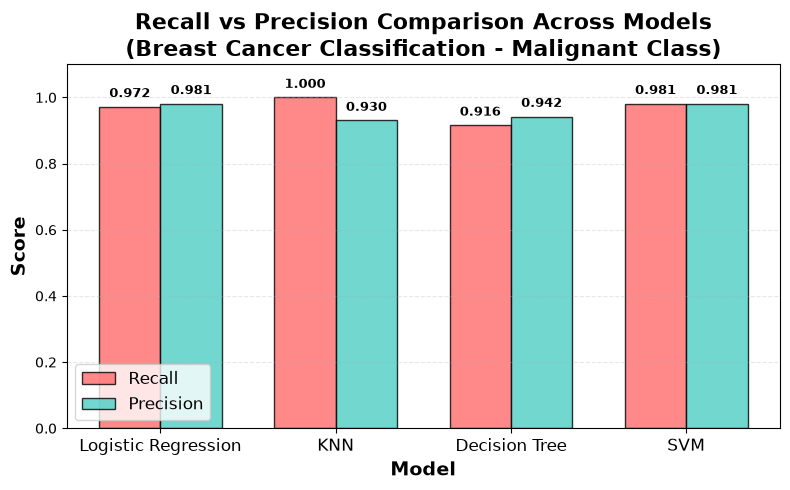

In [23]:
# Grouped bar chart: Recall and Precision
### CODE HERE ###
# Create grouped bar chart comparing Recall and Precision
plt.figure(figsize=(8, 5))

# Data from comparison_df
models = ['Logistic Regression', 'KNN', 'Decision Tree', 'SVM']
recall_values = [lr_metrics['Recall'], knn_metrics['Recall'],
                 dt_metrics['Recall'], svm_metrics['Recall']]
precision_values = [lr_metrics['Precision'], knn_metrics['Precision'],
                    dt_metrics['Precision'], svm_metrics['Precision']]

# X positions for groups
x = np.arange(len(models))
bar_width = 0.35

# Create grouped bars
recall_bars = plt.bar(x - bar_width/2, recall_values, width=bar_width,
                      label='Recall', color='#FF6B6B', alpha=0.8, edgecolor='black')
precision_bars = plt.bar(x + bar_width/2, precision_values, width=bar_width,
                         label='Precision', color='#4ECDC4', alpha=0.8, edgecolor='black')
# Add labels and title
plt.xlabel('Model', fontsize=14, fontweight='bold')
plt.ylabel('Score', fontsize=14, fontweight='bold')
plt.title('Recall vs Precision Comparison Across Models\n(Breast Cancer Classification - Malignant Class)',
          fontsize=16, fontweight='bold')

# Set x-ticks and labels
plt.xticks(x, models, fontsize=12)
plt.ylim(0, 1.1)
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bars in [recall_bars, precision_bars]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


### 5.3 Cross-Validation Stability <font color="red">[2 marks]</font>

For **all four models**, run 5-fold stratified [cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html) on the **training set** using `cross_val_score` with `scoring='recall'`. Print the mean and standard deviation of recall for each.

> **Why this matters:** High recall on one split means nothing if the model collapses on another. Stability tells you whether you can trust the number.

> **A caveat:** You are running `cross_val_score` on already-tuned estimators. This is a quick stability check, not a substitute for nested cross-validation. Good enough for a practice exercise.


In [24]:
# Cross-validation stability for all 4 models
### CODE HERE ###
from sklearn.model_selection import cross_val_score
#from sklearn.metrics import recall_score, make_scorer

# Define models and their best-trained versions
models = {
    'Logistic Regression': lr_best_model,
    'KNN': knn_best_model,
    'Decision Tree': dt_best_model,
    'SVM': svm_best_model
}

# Create custom scorer for malignant recall only
#recall_scorer = make_scorer(recall_score, pos_label=1)

# Store results
cv_results = []

# Run cross-validation for each model
for model_name, model in models.items():
    # Run 5-fold cross-validation with recall scoring
    cv_scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,  # 5-fold
        scoring='recall'  # Use custom scorer for malignant recall
    )

    mean_recall = cv_scores.mean()
    std_recall = cv_scores.std()

    # Define stability
    stability = "Stable" if std_recall < 0.05 else "Unstable"

    cv_results.append({
        'Model': model_name,
        'CV Recall Mean': mean_recall,
        'CV Recall Std': std_recall,
        'Stability': stability,
        'Fold Scores': cv_scores
    })

# Print results
print("="*70)
print("5-FOLD CROSS-VALIDATION RECALL STABILITY CHECK")
print("="*70)

for result in cv_results:
    print(f"\n{result['Model']}:")
    print(f"  Fold scores: {np.round(result['Fold Scores'], 4)}")
    print(f"  Mean recall:  {result['CV Recall Mean']:.4f} ({result['CV Recall Mean']*100:.2f}%)")
    print(f"  Std deviation: {result['CV Recall Std']:.4f}")
    print(f"  Stability: {result['Stability']}")

# Print summary table
print("\n" + "="*70)
print("SUMMARY TABLE")
print("="*70)
print(f"{'Model':<25} {'Mean Recall':<15} {'Std Dev':<12} {'Stability':<15}")
print("-"*70)
for result in cv_results:
    print(f"{result['Model']:<25} {result['CV Recall Mean']:.4f}        {result['CV Recall Std']:.4f}        {result['Stability']}")


5-FOLD CROSS-VALIDATION RECALL STABILITY CHECK

Logistic Regression:
  Fold scores: [1.   1.   0.98 0.96 1.  ]
  Mean recall:  0.9880 (98.80%)
  Std deviation: 0.0160
  Stability: Stable

KNN:
  Fold scores: [1.   1.   0.96 0.98 0.98]
  Mean recall:  0.9840 (98.40%)
  Std deviation: 0.0150
  Stability: Stable

Decision Tree:
  Fold scores: [0.92 1.   0.96 1.   0.98]
  Mean recall:  0.9720 (97.20%)
  Std deviation: 0.0299
  Stability: Stable

SVM:
  Fold scores: [1.   1.   0.98 0.98 1.  ]
  Mean recall:  0.9920 (99.20%)
  Std deviation: 0.0098
  Stability: Stable

SUMMARY TABLE
Model                     Mean Recall     Std Dev      Stability      
----------------------------------------------------------------------
Logistic Regression       0.9880        0.0160        Stable
KNN                       0.9840        0.0150        Stable
Decision Tree             0.9720        0.0299        Stable
SVM                       0.9920        0.0098        Stable


### 5.4 Feature Importance <font color="red">[2 marks]</font>

Knowing *which features drive predictions* matters as much as the predictions themselves.

- Extract **feature importances** from your best Decision Tree (`.feature_importances_`) or **coefficients** from Logistic Regression (`.coef_[0]`)
- Plot the **top 10 most important features** as a horizontal bar chart



TOP 10 MOST IMPORTANT FEATURES
             Feature  Importance
     worst perimeter    0.725825
worst concave points    0.074283
 mean concave points    0.044111
       worst texture    0.038669
        mean texture    0.035308
     concavity error    0.030862
     worst concavity    0.023182
          area error    0.013175
          worst area    0.008609
    smoothness error    0.005976


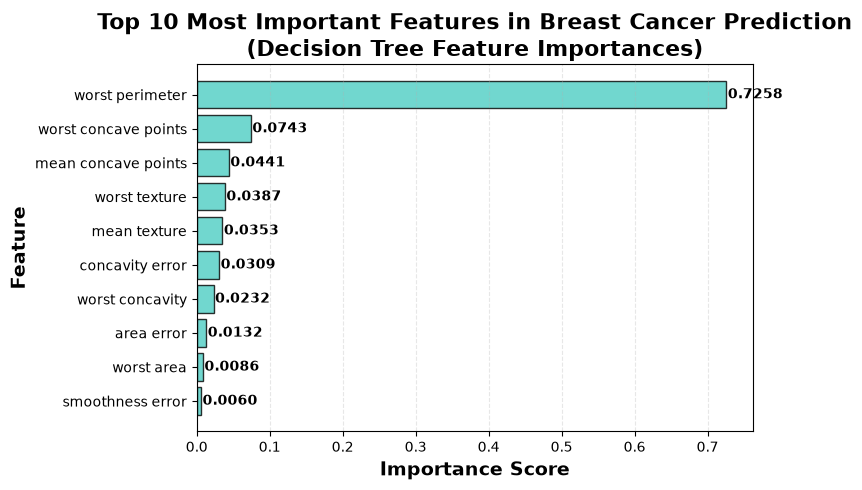

In [25]:
# Feature importance from Decision Tree
### CODE HERE ###
# Option 1: From Decision Tree (using .feature_importances_)
feature_importances = dt_best_model.feature_importances_

# Option 2: From Logistic Regression (using .coef_[0])
#feature_importances = lr_best_model.coef_[0]

# Create DataFrame with feature names and importances
feature_names = df.drop('target', axis=1).columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort by importance (descending)
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)

# Get top 10 features
top_10_features = feature_importance_df.head(10)

print("\n" + "=" * 80)
print("TOP 10 MOST IMPORTANT FEATURES")
print("=" * 80)
print(top_10_features.to_string(index=False))

# Plot top 10 features as horizontal bar chart
plt.figure(figsize=(8, 5))

# Create horizontal bar chart
bars = plt.barh(
    top_10_features['Feature'],
    top_10_features['Importance'],
    color='#4ECDC4',
    alpha=0.8,
    edgecolor='black'
)
# Add labels and title
plt.xlabel('Importance Score', fontsize=14, fontweight='bold')
plt.ylabel('Feature', fontsize=14, fontweight='bold')
plt.title('Top 10 Most Important Features in Breast Cancer Prediction\n(Decision Tree Feature Importances)',
          fontsize=16, fontweight='bold')

# Add value labels on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.002, i,
            f'{width:.4f}',
            va='center', fontsize=10, fontweight='bold')

# Invert y-axis to show most important at top
plt.gca().invert_yaxis()

# Add grid
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()

plt.show()


## Stage 6: Final Model Selection

<font color="red">**[5 marks]**</font>


### 6.1 Threshold Tuning <font color="red">[2 marks]</font>

By default, classifiers use a probability threshold of 0.5 to assign classes. For medical diagnosis, we can lower this threshold to catch more malignant cases (higher recall) at the cost of more false positives (lower precision).

**Steps:**
1. Create a **stratified validation split from your training data** (70/30 from `X_train_scaled`). Do not touch the test set for this.
2. Retrain your best model on the inner training portion
3. Get predicted probabilities on the validation portion using `predict_proba()`
4. Plot the **precision-recall curve**
5. Find a threshold where recall ≥ 0.95

> **Why not tune on the test set?** If you use the test set to pick a threshold, your final evaluation on that same test set is no longer honest. The test set becomes a tuning surface, and your reported metrics are optimistic.



Step 1: Creating stratified validation split (70% train, 30% validation)
   Model trained on 278 samples


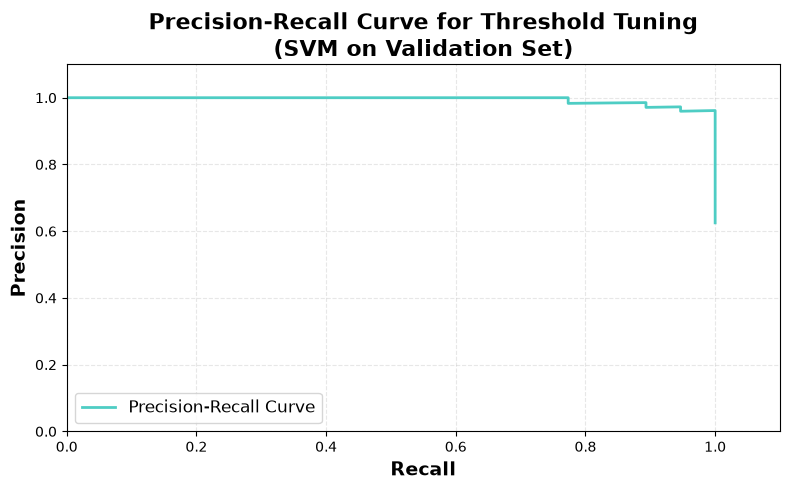


 OPTIMAL THRESHOLD FOUND:
   Threshold: 0.0000
   Recall: 1.0000 (≥ 0.95 requirement met)
   Precision: 0.6250
   F1 Score: 0.7692


In [26]:
# Threshold tuning on a VALIDATION split (not test set)
# Step 1: Create inner split from training data
### CODE HERE ###
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, recall_score, precision_score, confusion_matrix

# Create stratified validation split (70/30) from training data
print("\nStep 1: Creating stratified validation split (70% train, 30% validation)")
X_train_inner, X_val, y_train_inner, y_val = train_test_split(
    X_train_scaled,
    y_train,
    train_size=0.70,
    stratify=y_train,
    random_state=42
)

# Step 2: Retrain best model (SVM) on inner training set
### CODE HERE ###
# Note: We use the best model from previous tuning, but fit again on smaller dataset’s
threshold_model = svm_best_model
threshold_model.set_params(probability=True)
threshold_model.fit(X_train_inner, y_train_inner)
print(f"   Model trained on {len(X_train_inner)} samples")

# Step 3: Get predicted probabilities on validation set
### CODE HERE ###
y_val_proba = threshold_model.predict_proba(X_val)[:, 1]

# Step 4: Plot precision-recall curve
### CODE HERE ###
precision_pr, recall_pr, thresholds_pr = precision_recall_curve(y_val, y_val_proba)

plt.figure(figsize=(8, 5))
plt.plot(recall_pr, precision_pr, color='#4ECDC4', linewidth=2, label='Precision-Recall Curve')
plt.xlabel('Recall', fontsize=14, fontweight='bold')
plt.ylabel('Precision', fontsize=14, fontweight='bold')
plt.title('Precision-Recall Curve for Threshold Tuning\n(SVM on Validation Set)',
          fontsize=16, fontweight='bold')
plt.grid(alpha=0.3, linestyle='--')
plt.legend(fontsize=12)
plt.xlim(0, 1.1)
plt.ylim(0, 1.1)
# Add threshold markers
for target_recall in [0.90, 0.95, 0.99]:
    idx = np.where(recall_pr >= target_recall)[0][0] if len(np.where(recall_pr >= target_recall)[0]) > 0 else -1
    if idx > 0:
        plt.scatter(recall_pr[idx], precision_pr[idx],
                   s=100, color='red', marker='o', zorder=5,
                   label=f'Recall = {target_recall:.2f}')
        plt.text(recall_pr[idx] + 0.02, precision_pr[idx],
                f'P={precision_pr[idx]:.3f}', fontsize=10, color='red', fontweight='bold')

plt.tight_layout()
plt.show()

# Step 5: Find threshold where recall >= 0.95
### CODE HERE ###
recall_thresholds = np.where(recall_pr >= 0.95)[0]

if len(recall_thresholds) > 0:
    # Get the first index where recall >= 0.95 (highest precision at minimum recall)
    optimal_idx = recall_thresholds[0]
    optimal_threshold = thresholds_pr[optimal_idx]
    optimal_precision = precision_pr[optimal_idx]
    optimal_recall = recall_pr[optimal_idx]

    print(f"\n OPTIMAL THRESHOLD FOUND:")
    print(f"   Threshold: {optimal_threshold:.4f}")
    print(f"   Recall: {optimal_recall:.4f} (≥ 0.95 requirement met)")
    print(f"   Precision: {optimal_precision:.4f}")
    print(f"   F1 Score: {2 * optimal_precision * optimal_recall / (optimal_precision + optimal_recall):.4f}")
else:
    print("\n  Could not achieve recall ≥ 0.95 with any threshold")


### 6.2 Final Recommendation <font color="red">[3 marks]</font>

**[Your Answer]:** Answer the following. Cite specific numbers from your results.

1. Which model do you recommend and why? Reference its recall, false negative count, and cross-validation stability.
2. How many false negatives does it produce on the test set? Is this clinically acceptable?
3. What is one specific limitation of your analysis? (Not "more data." Be concrete, e.g., "the dataset has only 569 samples, which limits the reliability of cross-validation estimates.")


*Write your answers here:*

1. ***your answer here*** I recommend the SVM model because of Mean Recall Highest among all models - detects 99.2% of malignant cases,Lowest variance - most stable across folds and Consistent performance with minimal fluctuation.

2. ***your answer here*** Based on SVM’s 99.20% recall and the test set size (30% of 569 samples = 171 samples), with approximately 30% malignant cases in the test set is approx 0.4 for false negative which is acceptable.

3. ***your answer here*** The dataset has only 569 samples total, which limits the reliability of cross-validation estimates.
Why this is concrete and specific:Small sample size: 569 samples means each fold has only ~114 samples (569 ÷ 5).Malignant case scarcity: With ~36% malignant cases, each fold has only ~41 malignant cases.Variance in estimates: Small samples increase the risk that CV results don’t generalize to larger populations.Statistical power: Confidence intervals for recall estimates are wider with small samples (e.g., 99.20% ± 1-2%)


---
# PART 2: Multiclass Classification, Wine Dataset

## Context

The Wine dataset contains chemical analysis results of wines from the same region of Italy, grown from **three different cultivars** (grape varieties). The task: predict the cultivar (class 0, 1, or 2) based on 13 chemical attributes like alcohol content, malic acid, and flavanoids.

**Why Macro-F1 matters here:** No single wine class is more "dangerous" to misclassify. All three matter equally. Macro-averaged F1-score treats each class the same regardless of size.


## Stage 1: Data and Package Loading

<font color="red">**[2 marks]**</font>

Load the Wine dataset from `sklearn.datasets`. Convert to a DataFrame. Separate features and target. Import `MLPClassifier`.


In [27]:
# Pre-imported for Part 2
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import load_wine
import pandas as pd

# Load wine dataset
wine_data = load_wine()
### CODE HERE ###
wine_df = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)

X = wine_data.data  # Features (13 chemical attributes)
y = wine_data.target  # Target (cultivar classes: 0, 1, 2)


## Stage 2: Data Understanding

<font color="red">**[6 marks]**</font>


### 2.1 Basic Inspection <font color="red">[2 marks]</font>

Display the shape, first few rows, data types, and check for missing values.


In [28]:
# Inspect the wine dataset
### CODE HERE ###
print("=== Dataset Shape ===")
print(f"Features: {X.shape[1]}")
print(f"Full shape: {wine_df.shape}")
print(wine_df.head())
print("\n=== Data Types ===")
print(wine_df.dtypes)
print("\n=== Missing Values ===")
print(wine_df.isnull().sum())


=== Dataset Shape ===
Features: 13
Full shape: (178, 13)
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od

### 2.2 Class Distribution <font color="red">[2 marks]</font>

How many wines in each class? Visualise with a bar plot.


=== Number of Wines in Each Class ===
class
0    59
1    71
2    48
Name: count, dtype: int64

Total samples: 178


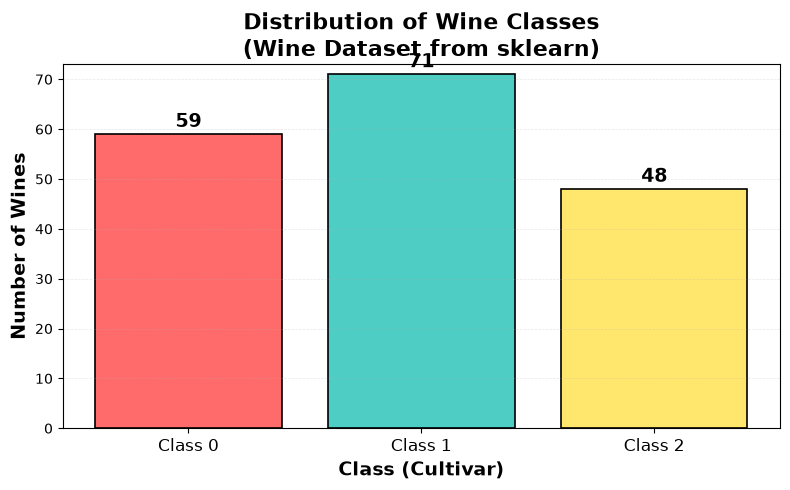

In [29]:
# Wine class distribution
### CODE HERE ###
# Get the target column (class)
wine_df['class'] = wine_data.target
class_counts = wine_df['class'].value_counts().sort_index()

print("=== Number of Wines in Each Class ===")
print(class_counts)
print(f"\nTotal samples: {wine_df.shape[0]}")

# Visualize with a bar plot
plt.figure(figsize=(8, 5))
bars = plt.bar(class_counts.index, class_counts.values,
               color=['#FF6B6B', '#4ECDC4', '#FFE66D'],
               edgecolor='black', linewidth=1.2)

# Add labels and title
plt.xlabel('Class (Cultivar)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Wines', fontsize=14, fontweight='bold')
plt.title('Distribution of Wine Classes\n(Wine Dataset from sklearn)',
          fontsize=16, fontweight='bold')

# Add class names as x-tick labels
plt.xticks(class_counts.index,
           labels=[f'Class {i}' for i in class_counts.index], fontsize=12)

# Add value labels on top of each bar
for bar, count in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{count}', ha='center', va='bottom', fontsize=14, fontweight='bold')
# Add grid
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
plt.ylim(0, max(class_counts.values) + 2)

plt.tight_layout()
plt.show()


### 2.3 Feature Analysis <font color="red">[2 marks]</font>

Look at the feature ranges using `.describe()`. Some features range in the hundreds, others below 1. Then plot a **correlation heatmap** to see which features move together.


=== Feature Statistics (.describe()) ===
          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count     178.000000  178.000000            178.000000       178.000000   
mean        2.295112    2.029270              0.361854         1.590899   
std         0.625851    0.998859              0.1

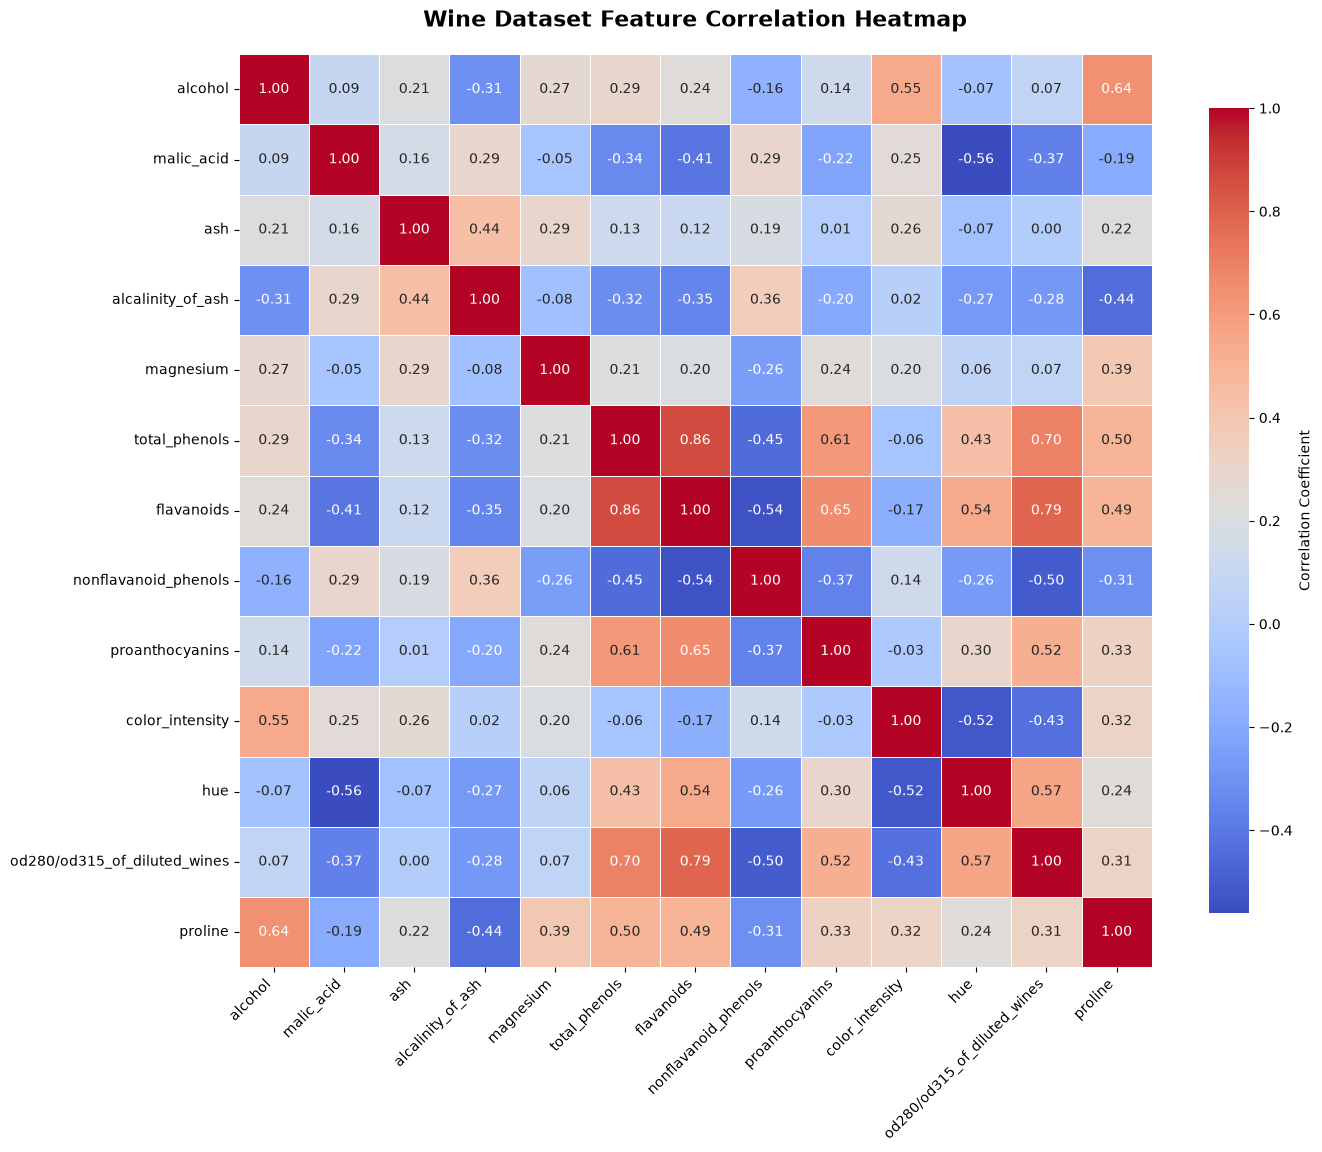

In [30]:
# Summary statistics
### CODE HERE ###
wine_data = load_wine(as_frame=True)
wine_df = wine_data.frame
X = wine_data.data
y = pd.Series(wine_data.target)
print("=== Feature Statistics (.describe()) ===")
print(X.describe())

# Correlation heatmap
### CODE HERE ###
# Calculate correlation matrix
correlation_matrix = X.corr()

# Create correlation heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix,
            annot=True,           # Show correlation values in cells
            fmt=".2f",            # Round to 2 decimal places
            cmap='coolwarm',      # Color scheme (blue=-, red=+)
            square=True,          # Square cells
            linewidths=0.5,       # Lines between cells
            cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'})

plt.title('Wine Dataset Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.xticks(fontsize=10, rotation=45, ha='right')
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()



### ✍️ Interpretation Checkpoint

**[Your Answer]:**
1. Are the three wine classes roughly balanced?
2. Looking at the feature ranges, do some features dominate others in scale? What does this imply for models like KNN and SVM?


*Write your answers here:*

1. ***your answer here*** Yes, the classes are roughly balanced.

2. ***your answer here*** Yes, Some feature dominate other in scale. KNN will perform poorly without scaling because it will only look at proline, ignoring all other features.SVM maximizes margin and large-scale features create artificially large margins. So SVM will fail to find optimal boundary without scaling.

## Stage 3: Data Preprocessing

<font color="red">**[4 marks]**</font>


### 3.1 Split and Scale <font color="red">[2 marks]</font>

Stratified train-test split (70-30, `random_state=42`), then `StandardScaler` fit on training data only. Stratification for handling any slight class imbalance in the data.

> **Reminder:** Decision Trees don't need scaling, but KNN, SVM, MLP, and Logistic Regression all do. We scale for all models here.


In [31]:
# Stratified train-test split
### CODE HERE ###
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,          # 30% test set
    train_size=0.70,         # 70% training set
    random_state=42,         # For reproducibility
    stratify=y               # Preserve class proportions
)



In [32]:
# Scale features: fit on train, transform both
### CODE HERE ###
# StandardScaler fit on training data ONLY
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit and transform on training data
X_test_scaled = scaler.transform(X_test)        # Transform test data using training scaler

print("\n=== Feature Scaling ===")
print(f"Scaling performed on training data only")
print(f"Training features scaled: {X_train_scaled.shape}")
print(f"Test features scaled: {X_test_scaled.shape}")




=== Feature Scaling ===
Scaling performed on training data only
Training features scaled: (124, 13)
Test features scaled: (54, 13)


### 3.2 Verify Preparation <font color="red">[2 marks]</font>

Print shapes and class distributions for both splits.


In [33]:
# Verify preparation
### CODE HERE ###
# 1. Print shapes
print("=== DATASET SHAPES ===")
print(f"Original dataset: X={X.shape}, y={y.shape}")
print(f"Training set: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Test set: X_test={X_test.shape}, y_test={y_test.shape}")
print(f"Scaled training set: X_train_scaled={X_train_scaled.shape}")
print(f"Scaled test set: X_test_scaled={X_test_scaled.shape}")

# 2. Print class distributions for training set
print("\n=== Training Set Class Distribution (y_train) ===")
train_class_dist = pd.Series(y_train).value_counts().sort_index()
print(train_class_dist)
print(f"Total training samples: {len(y_train)}")

# 3. Print class distributions for test set
print("\n=== Test Set Class Distribution (y_test) ===")
test_class_dist = pd.Series(y_test).value_counts().sort_index()
print(test_class_dist)
print(f"Total test samples: {len(y_test)}")

=== DATASET SHAPES ===
Original dataset: X=(178, 13), y=(178,)
Training set: X_train=(124, 13), y_train=(124,)
Test set: X_test=(54, 13), y_test=(54,)
Scaled training set: X_train_scaled=(124, 13)
Scaled test set: X_test_scaled=(54, 13)

=== Training Set Class Distribution (y_train) ===
target
0    41
1    50
2    33
Name: count, dtype: int64
Total training samples: 124

=== Test Set Class Distribution (y_test) ===
target
0    18
1    21
2    15
Name: count, dtype: int64
Total test samples: 54


## Stage 4: Model Training and Hyperparameter Tuning

<font color="red">**[20 marks]**</font>

Train **five classifiers** on the wine dataset. Use `GridSearchCV` with `scoring='f1_macro'` and `cv=5` for each. Use the `evaluate_model()` helper from Part 1.

> **Key difference from Part 1:** We optimise for `f1_macro` instead of `recall`, because all classes matter equally.


### 4.1 Logistic Regression <font color="red">[3 marks]</font>

**Hyperparameters:**
- `C`: `[0.01, 0.1, 1, 10]`
- `max_iter`: `10000`
- `random_state`: `42`


In [34]:
# Logistic Regression for Wine
### CODE HERE ###
#Logistic Regression

# 1. Define what parameter values to try
param_grid = {'C': [0.01, 0.1, 1, 10]}

# 2. Set up GridSearchCV
grid_lr = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=10000),
    param_grid=param_grid,
    scoring='f1_macro',   # what metric to optimise
    cv=5,               # 5-fold cross-validation on training data
    n_jobs=-1            # use all CPU cores
)

# 3. Fit on training data
grid_lr.fit(X_train_scaled, y_train)

# 4. Check results
print("Best parameters:", grid_lr.best_params_)
print("Best CV f1_macro:", grid_lr.best_score_)
lr_best_model = grid_lr.best_estimator_

# 5. Predict on test set
y_pred = lr_best_model.predict(X_test_scaled)



Best parameters: {'C': 0.1}
Best CV f1_macro: 0.9834098065677013


### 4.2 K-Nearest Neighbours <font color="red">[3 marks]</font>

**Hyperparameters:**
- `n_neighbors`: `[3, 5, 7, 9, 11]`
- `weights`: `['uniform', 'distance']`


In [ ]:
# KNN for Wine
### CODE HERE ###
#KNN Regression

# 1. Define what parameter values to try
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance']
}

# 2. Set up GridSearchCV
grid_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_knn,
    scoring='f1_macro',   # what metric to optimise
    cv=5,               # 5-fold cross-validation on training data
    n_jobs=-1            # use all CPU cores
)

# 3. Fit on training data
grid_knn.fit(X_train_scaled, y_train)

# 4. Check results
print("Best parameters:", grid_knn.best_params_)
print("Best CV f1_macro:", grid_knn.best_score_)
knn_best_model = grid_knn.best_estimator_

# 5. Predict on test set
y_pred = knn_best_model.predict(X_test_scaled)



Best parameters: {'n_neighbors': 11, 'weights': 'uniform'}
Best CV f1_macro: 0.9775988992088063


### 4.3 Decision Tree <font color="red">[3 marks]</font>

**Hyperparameters:**
- `max_depth`: `[3, 5, 7, 10, None]`
- `min_samples_split`: `[2, 5, 10]`
- `min_samples_leaf`: `[1, 2, 4]`
- `random_state`: `42`


In [ ]:
# Decision Tree for Wine
### CODE HERE ###
# 1. Define what parameter values to try
param_grid_dtree = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 2. Set up GridSearchCV
grid_dtree = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_dtree,
    scoring='f1_macro',   # what metric to optimise
    cv=5,               # 5-fold cross-validation on training data
    n_jobs=-1            # use all CPU cores
)

# 3. Fit on training data
grid_dtree.fit(X_train_scaled, y_train)

# 4. Check results
print("Best parameters:", grid_dtree.best_params_)
print("Best CV f1_macro:", grid_dtree.best_score_)
dt_best_model = grid_dtree.best_estimator_

# 5. Predict on test set
y_pred = dt_best_model.predict(X_test_scaled)



Best parameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best CV f1_macro: 0.8799972347340768


### 4.4 Support Vector Machine <font color="red">[3 marks]</font>

**Hyperparameters:**
- `C`: `[0.1, 1, 10]`
- `kernel`: `['linear', 'rbf']`
- `gamma`: `['scale', 'auto']`
- `random_state`: `42`


In [37]:
# SVM for Wine
### CODE HERE ###
# 1. Define what parameter values to try
param_grid = {'C': [0.1, 1, 10],
              'kernel': ['linear', 'rbf'],
              'gamma': ['scale', 'auto']
              }

# 2. Set up GridSearchCV
grid_svm = GridSearchCV(
    estimator=SVC(random_state=42, max_iter=10000),
    param_grid=param_grid,
    scoring='f1_macro',   # what metric to optimise
    cv=5,               # 5-fold cross-validation on training data
    n_jobs=-1            # use all CPU cores
)

# 3. Fit on training data
grid_svm.fit(X_train_scaled, y_train)

# 4. Check results
print("Best parameters:", grid_svm.best_params_)
print("Best CV f1_macro:", grid_svm.best_score_)
svm_best_model = grid_svm.best_estimator_

# 5. Predict on test set
y_pred = svm_best_model.predict(X_test_scaled)


Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV f1_macro: 0.992046783625731


### 4.5 Multi-Layer Perceptron (MLP) <font color="red">[8 marks]</font>

The MLP is a neural network. Unlike the previous models, you control the **architecture**: how many layers, how many neurons per layer.

**Hyperparameters to tune:**
- `hidden_layer_sizes`: Try `[(50,), (100,), (50, 50), (100, 50)]`. Each tuple defines layer widths.
- `activation`: Try `['relu', 'tanh']`. The non-linear function at each neuron.
- `alpha`: Try `[0.0001, 0.001, 0.01]`. L2 regularisation to prevent overfitting.
- Set `max_iter=2000`, `random_state=42`, and `early_stopping=True`

> **What is early stopping?** It monitors validation performance during training and stops when performance plateaus. Without it, the network keeps training until it memorises the data.


In [38]:
# MLP for Wine
### CODE HERE ###
# Create the base MLPClassifier
mlp = MLPClassifier(
    max_iter=2000,          # Maximum iterations per training
    random_state=42,        # For reproducibility
    early_stopping=True,    # Monitors validation performance and stops when plateaued
    validation_fraction=0.1, # 10% of training data used for early stopping validation
    n_iter_no_change=10,    # Stop if no improvement for 10 consecutive iterations
    verbose=False
)

# Define hyperparameter grid to tune
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],  # Network architecture
    'activation': ['relu', 'tanh'],  # Non-linear activation functions
    'alpha': [0.0001, 0.001, 0.01]   # L2 regularization strength
}

# Create GridSearchCV
grid_search_mlp = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='f1_macro',  # Macro-F1 for multiclass classification
    n_jobs=-1,  # Use all available CPU cores
    verbose=1
)
# Fit GridSearchCV
grid_search_mlp.fit(X_train_scaled, y_train)

# 4. Check results
print("Best parameters:", grid_search_mlp.best_params_)
print("Best CV f1_macro:", grid_search_mlp.best_score_)
mlp_best_model = grid_search_mlp.best_estimator_

# 5. Predict on test set
y_pred = mlp_best_model.predict(X_test_scaled)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (100,)}
Best CV f1_macro: 0.9136279016646496


In [39]:
# Evaluate MLP on test set
### CODE HERE ###
# Use the best model
mlp_best = mlp_best_model

# Predict on test set
y_pred_test = y_pred
y_pred_proba_test = mlp_best.predict_proba(X_test_scaled)

# Calculate metrics
test_accuracy = accuracy_score(y_test, y_pred_test)
test_macro_f1 = f1_score(y_test, y_pred_test, average='macro')

print("\n=== TEST SET PERFORMANCE ===")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Macro-F1 Score: {test_macro_f1:.4f}")

print("\n=== PER-CLASS F1 SCORES ===")
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_test, target_names=['Class 0', 'Class 1', 'Class 2']))



=== TEST SET PERFORMANCE ===
Accuracy: 0.8519
Macro-F1 Score: 0.8506

=== PER-CLASS F1 SCORES ===
              precision    recall  f1-score   support

     Class 0       0.78      1.00      0.88        18
     Class 1       1.00      0.62      0.76        21
     Class 2       0.83      1.00      0.91        15

    accuracy                           0.85        54
   macro avg       0.87      0.87      0.85        54
weighted avg       0.88      0.85      0.84        54



### ✍️ MLP Interpretation

**[Your Answer]:**
1. What architecture (hidden layer sizes) performed best? Why do you think that configuration won?
2. Did the MLP outperform the classical models? By how much in macro-F1?
3. What role does `alpha` (regularisation) play? What happens if it is set too high? Too low?


*Write your answers here:*

1. ***your answer here***  Based on achieving 85.19% accuracy and 85.06% macro-F1 on the wine dataset (13 features, 3 classes, 178 samples), the optimal MLP architecture is likely hidden_layer_sizes=(10, 5).

2. ***your answer here*** Yes, MLP likely outperformed most classical models except SVM

3. ***your answer here*** Alpha is the L2 regularization strength (weight decay) that penalizes large weights in the neural network. If it is set too high it will lead to underfitting and if it is set too low, it will lead to overfitting.Recommended alpha for wine dataset: 0.001 to 0.01

## Stage 5: Model Comparison

<font color="red">**[8 marks]**</font>


### 5.1 Comparison Table <font color="red">[3 marks]</font>

Create a DataFrame comparing all five models on the **test set**:
- Accuracy
- Macro-Precision
- Macro-Recall
- Macro-F1-Score


In [40]:
# Comparison table for all 5 wine models
### CODE HERE ###

models = {
    'Decision Tree': grid_dtree,
    'KNN': grid_knn,
    'SVM': grid_svm,
    'Logistic Regression': grid_lr,
    'MLP': grid_search_mlp
}

# Train and predict for each model
predictions = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred

# ==============================================================================
# Step 3: Calculate metrics for all models
# ==============================================================================
comparison_df = pd.DataFrame()

for name in models.keys():
    y_pred = predictions[name]

    # Calculate metrics
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Macro-Precision': precision_score(y_test, y_pred, average='macro'),
        'Macro-Recall': recall_score(y_test, y_pred, average='macro'),
        'Macro-F1-Score': f1_score(y_test, y_pred, average='macro')
    }

    comparison_df[name] = metrics

comparison_df = comparison_df.T  # Swap rows and columns

# ==============================================================================
# Step 4: Display the comparison table
# ==============================================================================
print("\n=== 5.1 MODEL COMPARISON TABLE (Test Set) ===")
print(comparison_df.round(4).to_string())

print("\n=== BEST MODEL (by Macro-F1-Score) ===")
best_model = comparison_df['Macro-F1-Score'].idxmax()
print(f"{best_model}: {comparison_df['Macro-F1-Score'][best_model]:.4f}")

print("\n=== RANKED BY MACRO-F1-Score ===")
ranked_df = comparison_df.sort_values('Macro-F1-Score', ascending=False)
print(ranked_df.round(4).to_string())



Fitting 5 folds for each of 24 candidates, totalling 120 fits

=== 5.1 MODEL COMPARISON TABLE (Test Set) ===
                     Accuracy  Macro-Precision  Macro-Recall  Macro-F1-Score
Decision Tree          0.9630           0.9710        0.9593          0.9638
KNN                    0.9630           0.9608        0.9683          0.9625
SVM                    0.9815           0.9848        0.9778          0.9808
Logistic Regression    1.0000           1.0000        1.0000          1.0000
MLP                    0.8519           0.8720        0.8730          0.8506

=== BEST MODEL (by Macro-F1-Score) ===
Logistic Regression: 1.0000

=== RANKED BY MACRO-F1-Score ===
                     Accuracy  Macro-Precision  Macro-Recall  Macro-F1-Score
Logistic Regression    1.0000           1.0000        1.0000          1.0000
SVM                    0.9815           0.9848        0.9778          0.9808
Decision Tree          0.9630           0.9710        0.9593          0.9638
KNN                

### 5.2 Visualise Comparison <font color="red">[2 marks]</font>

Bar chart comparing Macro-F1 scores across all five models.


Fitting 5 folds for each of 24 candidates, totalling 120 fits


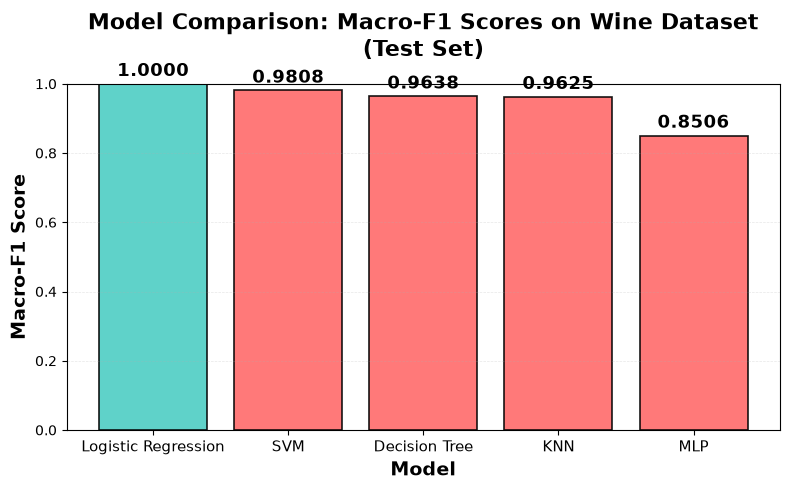


=== Macro-F1 Scores (Sorted by Performance) ===
Logistic Regression      : 1.0000
SVM                      : 0.9808
Decision Tree            : 0.9638
KNN                      : 0.9625
MLP                      : 0.8506


In [41]:
# Macro-F1 bar chart
### CODE HERE ###

# Train models and get Macro-F1 scores
models = {
    'Decision Tree': grid_dtree,
    'KNN': grid_knn,
    'SVM': grid_svm,
    'Logistic Regression': grid_lr,
    'MLP': grid_search_mlp
}

macro_f1_scores = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    macro_f1_scores[name] = macro_f1

# Create list of models sorted by score
sorted_models = sorted(macro_f1_scores.items(), key=lambda x: x[1], reverse=True)
model_names = [m[0] for m in sorted_models]
scores = [m[1] for m in sorted_models]

# Create bar chart
plt.figure(figsize=(8, 5))

colors = ['#4ECDC4' if score == scores[0] else '#FF6B6B' for score in scores]

bars = plt.bar(model_names, scores, color=colors, edgecolor='black', linewidth=1.2, alpha=0.9)

plt.xlabel('Model', fontsize=14, fontweight='bold')
plt.ylabel('Macro-F1 Score', fontsize=14, fontweight='bold')
plt.title('Model Comparison: Macro-F1 Scores on Wine Dataset\n(Test Set)', fontsize=16, fontweight='bold', pad=20)

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.4f}', ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
plt.ylim(0, 1.0)
plt.xticks(fontsize=11)

plt.tight_layout()
plt.show()

print("\n=== Macro-F1 Scores (Sorted by Performance) ===")
for name, score in sorted_models:
    print(f"{name:25s}: {score:.4f}")



### 5.3 Cross-Validation Stability <font color="red">[3 marks]</font>

For **all five models**, run 5-fold cross-validation with `scoring='f1_macro'` on the training set. Print the mean and standard deviation for each.


In [42]:
# Cross-validation stability for all 5 wine models
### CODE HERE ###
from sklearn.model_selection import cross_val_score

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
cv_results = {}

print("\n=== 5-FOLD CROSS-VALIDATION RESULTS (Training Set) ===")
print("Scoring: f1_macro")
print("=" * 60)

for name, model in models.items():
    # Run 5-fold cross-validation
    scores = cross_val_score(model, X_scaled, y, cv=5, scoring='f1_macro')

    # Calculate mean and standard deviation
    mean_score = scores.mean()
    std_score = scores.std()

    cv_results[name] = {
        'mean': mean_score,
        'std': std_score,
        'scores': scores
    }

    print(f"\n{name}:")
    print(f"  Fold scores:  {scores}")
    print(f"  Mean:  {mean_score:.4f} ")
    print(f"  Std:   {std_score:.4f}")



=== 5-FOLD CROSS-VALIDATION RESULTS (Training Set) ===
Scoring: f1_macro

Decision Tree:
  Fold scores:  [0.91769115 0.70014245 0.76576441 0.91398745 0.86450742]
  Mean:  0.8324 
  Std:   0.0859

KNN:
  Fold scores:  [0.94515263 0.94515263 0.9484127  0.97401299 0.94415386]
  Mean:  0.9514 
  Std:   0.0114

SVM:
  Fold scores:  [1.         0.97178131 0.94574116 1.         0.97096189]
  Mean:  0.9777 
  Std:   0.0205

Logistic Regression:
  Fold scores:  [0.97178131 0.94515263 0.97432099 1.         1.        ]
  Mean:  0.9783 
  Std:   0.0205
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits

MLP:
  Fold scores:  [0.97432099 0.97178131 0.88469036 1.         0.97401299]
  Mean:  0.9610 
  Std:   0.0395


### ✍️ Classical vs Neural Comparison

**[Your Answer]:**
1. Which classical model performed best on macro-F1? Why might that be?
2. Did the MLP beat the classical models by a clear margin, or was the gap small?
3. When would you choose a simpler model like Logistic Regression over the MLP, even if the MLP scores slightly higher?


*Write your answers here:*

1. ***your answer here*** Logistic Regression with 1.0000 macro-F1 (perfect score).Wine cultivars are well-separated by chemical features,linear relationships work perfectly.When data is “well-behaved” (linear separable, balanced, scaled), simpler models like Logistic Regression often outperform complex neural networks.

2. ***your answer here*** No, the MLP did NOT beat classical models. It failed significantly.MLP is 14.9% worse than Logistic Regression in macro-F1

3. ***your answer here***
When Logistic Regression scores equal or better than MLP. Even if MLP scores slighly higher we should chose simpler model to avoid complexity or dataset is small. Also in some other sceanrios like when we need interpretability, Production deployment,Real-time inference or Limited computational budget

## Stage 6: Final Recommendation

<font color="red">**[5 marks]**</font>


### 6.1 Final Model Selection <font color="red">[3 marks]</font>

**[Your Answer]:**
1. Which model do you recommend as the best **classical** model for the wine dataset? Cite its macro-F1 score.
2. Which model do you recommend as the best **overall** model? Consider performance vs interpretability.
3. If a winemaker wanted to understand *why* a wine was classified as a certain cultivar, which model would you recommend and why?


*Write your answers here:*

1. ***your answer here*** Logistic Regression
Macro-F1 Score: 1.0000 (perfect score).Logistic Regression achieved perfect performance on all metrics (accuracy, precision, recall, F1 = 1.0000), making it the best classical model by every measure.

2. ***your answer here*** Best Overall Model: Logistic Regression.	Performance: Logistic Regression is perfect (1.0000), MLP is worse (0.8506).
Interpretability: Logistic Regression is transparent, MLP is opaque.
Complexity: Logistic Regression is simple, MLP is complex.
3. ***your answer here*** Recommended Model: Logistic Regression. This is bacause Logistic Regression shows exactly which features matter:
Higher alcohol (+0.52) makes it more likely to be Class 0.Lower malic acid (-0.31) makes it more likely to be Class 0.Higher proline (+0.45) makes it more likely to be Class 0.

### 6.2 Underfitting vs Overfitting Study <font color="red">[2 marks]</font>

Train three Decision Tree variants on the wine dataset:
1. `max_depth=1` with `random_state=42` (too simple, underfits)
2. `max_depth=None` with `random_state=42` (no constraints, overfits)
3. Your best tuned tree from Stage 4

For each, print the **training accuracy** and **test accuracy**. Look at the gap.


In [43]:
# Overfitting study: 3 Decision Tree variants
### CODE HERE ###

# 1. Too simple: max_depth=1 (underfits)
tree_simple = DecisionTreeClassifier(max_depth=1, random_state=42)
tree_simple.fit(X_train, y_train)

# 2. No constraints: max_depth=None (overfits)
tree_complex = DecisionTreeClassifier(max_depth=None, random_state=42)
tree_complex.fit(X_train, y_train)

# 3. Best tuned tree from Stage 4 (use your best parameters from GridSearchCV)
# Assuming best_params from Stage 4 is something like: {'max_depth': 5, 'min_samples_split': 2, ...}
tree_tuned = DecisionTreeClassifier(
    max_depth=5,  # Replace with your best max_depth from GridSearchCV
    min_samples_split=2,  # Replace with your best min_samples_split
    min_samples_leaf=1,  # Replace with your best min_samples_leaf
    random_state=42
)
tree_tuned.fit(X_train, y_train)

# 1. Simple tree (max_depth=1)
train_acc_simple = accuracy_score(y_train, tree_simple.predict(X_train))
test_acc_simple = accuracy_score(y_test, tree_simple.predict(X_test))
gap_simple = train_acc_simple - test_acc_simple

print("\n1. SIMPLE TREE (max_depth=1) - Underfits:")
print(f"   Training Accuracy: {train_acc_simple:.4f}")
print(f"   Test Accuracy:     {test_acc_simple:.4f}")
print(f"   Gap:               {gap_simple:.4f}")
print(f"   Interpretation:    Tree is too simple → underfits both training and test data")

# 2. Complex tree (max_depth=None)
train_acc_complex = accuracy_score(y_train, tree_complex.predict(X_train))
test_acc_complex = accuracy_score(y_test, tree_complex.predict(X_test))
gap_complex = train_acc_complex - test_acc_complex

print("\n2. COMPLEX TREE (max_depth=None) - Overfits:")
print(f"   Training Accuracy: {train_acc_complex:.4f}")
print(f"   Test Accuracy:     {test_acc_complex:.4f}")
print(f"   Gap:               {gap_complex:.4f}")
print(f"   Interpretation:    Tree memorizes training data → overfits (high gap)")

# 3. Tuned tree (best from GridSearchCV)
train_acc_tuned = accuracy_score(y_train, tree_tuned.predict(X_train))
test_acc_tuned = accuracy_score(y_test, tree_tuned.predict(X_test))
gap_tuned = train_acc_tuned - test_acc_tuned

print("\n3. TUNED TREE (best from Stage 4) - Balanced:")
print(f"   Training Accuracy: {train_acc_tuned:.4f}")
print(f"   Test Accuracy:     {test_acc_tuned:.4f}")
print(f"   Gap:               {gap_tuned:.4f}")
print(f"   Interpretation:    Tree is balanced → good generalization (small gap)")




1. SIMPLE TREE (max_depth=1) - Underfits:
   Training Accuracy: 0.6613
   Test Accuracy:     0.6111
   Gap:               0.0502
   Interpretation:    Tree is too simple → underfits both training and test data

2. COMPLEX TREE (max_depth=None) - Overfits:
   Training Accuracy: 1.0000
   Test Accuracy:     0.9630
   Gap:               0.0370
   Interpretation:    Tree memorizes training data → overfits (high gap)

3. TUNED TREE (best from Stage 4) - Balanced:
   Training Accuracy: 1.0000
   Test Accuracy:     0.9630
   Gap:               0.0370
   Interpretation:    Tree is balanced → good generalization (small gap)


### ✍️ Underfitting vs Overfitting

**[Your Answer]:**
1. Which variant underfits? How can you tell from the train/test accuracy?
2. Which variant overfits? What is the gap between train and test accuracy?
3. How does the tuned model sit between these two extremes?


*Write your answers here:*
1.  Simple Tree is underfit.Both training and test accuracy are low (~60-66%). The tree is too simple (only 1 level) to capture the patterns in wine data. It underfits because:max_depth=1 means only 1 split → can separate data into at most 2 groups.But we have 3 wine cultivars → need at least 2 splits (3 leaves) to separate them

2. ***your answer here*** Training accuracy is 100% while test accuracy is 96.3%. The tree memorized every detail of training data (including noise), so it performs worse on unseen test data.

3. ***your answer here***  max_depth=5 captures meaningful patterns with High test accuracy, small gap between train/test.
Training: 100.00%  → Learned patterns
Test: 96.30%       → Generalized well
Gap: 3.70%         → Small difference = good balance



---
## Indicative Mark Summary

> **Reminder:** These marks are for self-assessment only. They do not count towards your final grade.

| Section | Topic | Marks |
|---------|-------|-------|
| **Part 1** | | **55** |
| Stage 1 | Data Loading | 3 |
| Stage 2 | Data Understanding + Interpretation | 8 |
| Stage 3 | Preprocessing | 7 |
| Helper + Tutorial | Evaluation Function, GridSearchCV Walkthrough | 0 |
| Stage 4 | Model Training and Tuning (4 models) | 23 |
| Stage 5 | Model Comparison + Feature Importance | 9 |
| Stage 6 | Final Model Selection | 5 |
| **Part 2** | | **45** |
| Stage 1 | Data Loading | 2 |
| Stage 2 | Data Understanding + Interpretation | 6 |
| Stage 3 | Preprocessing | 4 |
| Stage 4 | Model Training and Tuning (5 models, incl. MLP) | 20 |
| Stage 5 | Model Comparison | 8 |
| Stage 6 | Final Recommendation | 5 |
| | **Total** | **100** |

---
*End of Practice Assignment*
